In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 1. Загрузка данных

df = pd.read_csv("../data/almaty_apartments_with_id.csv")
df = df.dropna(subset=['price', 'area', 'number_of_rooms'])

# --- НОВОЕ: Очистка от жестких выбросов (убираем 1% самых дешевых и 1% самых дорогих) ---
q_low = df['price'].quantile(0.01)
q_hi  = df['price'].quantile(0.99)
df = df[(df['price'] > q_low) & (df['price'] < q_hi)]

# Также убираем странные площади (например, меньше 15 кв.м. или больше 400 кв.м.)
df = df[(df['area'] >= 15) & (df['area'] <= 400)]
# ----------------------------------------------------------------------------------------

# 2. Инженерия признаков
DATASET_YEAR = 2025
df['house_age'] = DATASET_YEAR - df['year_of_construction']

num_cols = ['area', 'number_of_rooms', 'floor', 'house_age']
cat_cols = ['district', 'structure_type', 'quality']

df[cat_cols] = df[cat_cols].astype(str)

X = df[num_cols + cat_cols]
y = df['price']

# 3. Настройка Pipeline
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# 4. Сравнение моделей
models = [
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('XGBoost', xgb.XGBRegressor(random_state=42)),
    ('CatBoost', CatBoostRegressor(verbose=0, random_state=42))
]

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MAPE': make_scorer(mean_absolute_percentage_error),
    'R2': make_scorer(r2_score)
}

results = []
print("Обучаем модели на очищенных и перемешанных данных...")

# --- НОВОЕ: Настраиваем правильную кросс-валидацию с перемешиванием ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models:
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Используем наш kf вместо просто cv=5
    cv_scores = cross_validate(model_pipe, X, y, cv=kf, scoring=scoring)
    
    results.append({
        'Model': name,
        'MAE': cv_scores['test_MAE'].mean(),
        'MAPE': cv_scores['test_MAPE'].mean(),
        'R2': cv_scores['test_R2'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
display(results_df)

Обучаем модели на очищенных и перемешанных данных...


,Model,MAE,MAPE,R2
0,CatBoost,6.754141e+06,0.132503,0.862647
1,Random Forest,6.496266e+06,0.127422,0.860502
2,XGBoost,6.845095e+06,0.133145,0.852552


In [28]:
df.shape

(11620, 10)

In [29]:
import joblib

# 1. Берем нашего победителя с лучшими параметрами
# (В данном случае используем базовый CatBoost, так как он и так выдал 0.86)
final_model_almaty = CatBoostRegressor(verbose=0, random_state=42)

# 2. Собираем итоговый конвейер
final_pipeline_almaty = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model_almaty)
])

# 3. Обучаем на ВСЕХ данных (X, y уже содержат очищенные данные из предыдущего шага)
print("Начинаю финальное обучение модели для Алматы...")
final_pipeline_almaty.fit(X, y)
print("Обучение завершено успешно!")

# 4. Сохраняем в файл. Назовем его 'almaty_pipeline.joblib'
joblib.dump(final_pipeline_almaty, 'almaty_pipeline.joblib')
print("Модель для Алматы сохранена в файл 'almaty_pipeline.joblib'")

Начинаю финальное обучение модели для Алматы...
Обучение завершено успешно!
Модель для Алматы сохранена в файл 'almaty_pipeline.joblib'


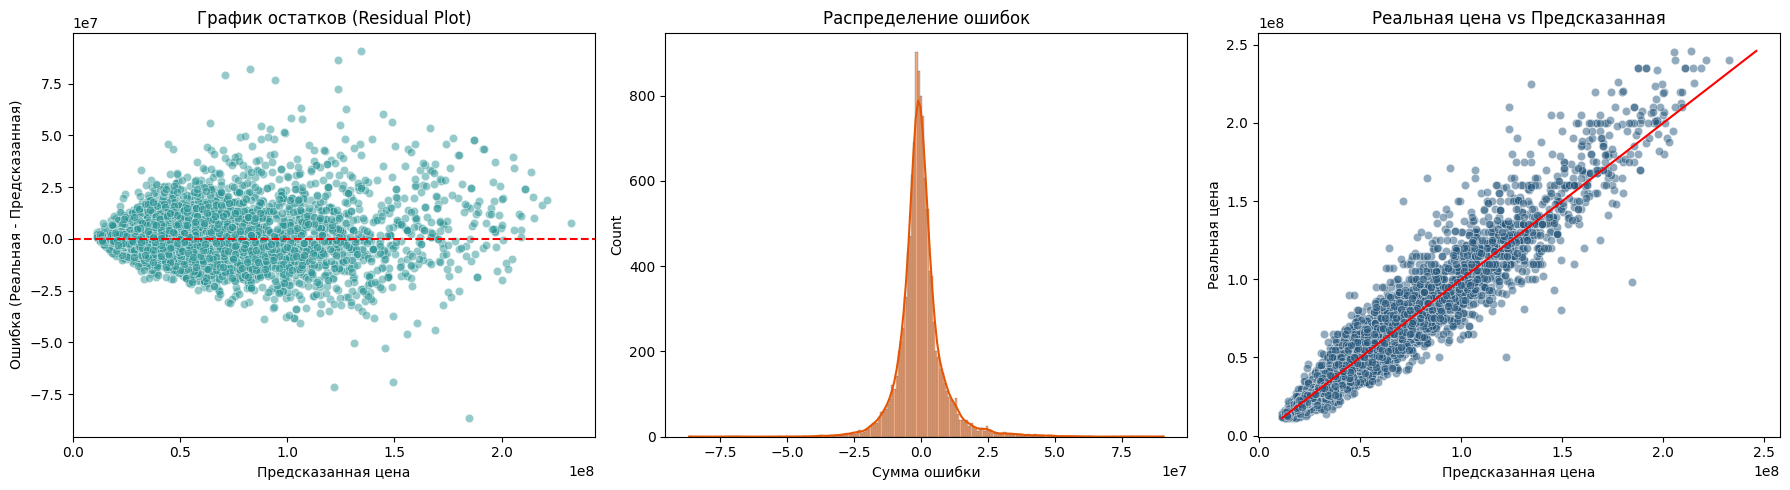

In [30]:
# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (КАК У ПРОФИ) ===
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем предсказания нашей финальной модели на всех данных
y_pred = final_pipeline_almaty.predict(X)

# Создаем холст для трех графиков
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# 1. График остатков (Residual Plot)
residuals = y - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], color='#2D9596', alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('График остатков (Residual Plot)')
axes[0].set_xlabel('Предсказанная цена')
axes[0].set_ylabel('Ошибка (Реальная - Предсказанная)')

# 2. Распределение ошибок (Residual Distribution)
sns.histplot(residuals, kde=True, ax=axes[1], color='#E55604')
axes[1].set_title('Распределение ошибок')
axes[1].set_xlabel('Сумма ошибки')

# 3. Реальная цена vs Предсказанная цена (Actual vs Predicted)
sns.scatterplot(x=y_pred, y=y, ax=axes[2], color='#26577C', alpha=0.5)
axes[2].set_title('Реальная цена vs Предсказанная')
axes[2].set_xlabel('Предсказанная цена')
axes[2].set_ylabel('Реальная цена')

# Рисуем идеальную диагональ (где предсказание = реальности)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='-')

plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
import joblib

print("Подготавливаем сетку гиперпараметров для CatBoost...")

# 1. Задаем сетку параметров. 
# ВАЖНО: мы пишем префикс 'model__', так как наш CatBoost лежит внутри Pipeline под именем 'model'
param_grid = {
    'model__depth': [4, 6, 8],               # Глубина дерева (насколько сложные закономерности оно ищет)
    'model__learning_rate': [0.05, 0.1],     # Шаг обучения
    'model__iterations': [100, 300, 500]     # Количество деревьев
}

# 2. Настраиваем GridSearchCV
# Он переберет все комбинации (3 * 2 * 3 = 18 комбинаций) 
# Каждую проверит 3 раза (cv=3). Итого: 54 обучения модели!
grid_search = GridSearchCV(
    estimator=final_pipeline_almaty, # Наш пайплайн с обработкой пропусков и категорий
    param_grid=param_grid,
    cv=3, 
    scoring='r2', 
    verbose=2, # Чтобы мы видели процесс в консоли
    n_jobs=-1  # Использовать все ядра процессора для ускорения
)

print("Начинаем подбор гиперпараметров! Идем пить чай, это займет пару минут...")
grid_search.fit(X, y)

# 3. Выводим результаты
print("\n=== РЕЗУЛЬТАТЫ ТЮНИНГА ===")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2 после тюнинга: {grid_search.best_score_:.4f}")

# 4. Сохраняем самую умную, прокачанную модель
best_tuned_model = grid_search.best_estimator_
joblib.dump(best_tuned_model, 'almaty_pipeline_tuned.joblib')
print("Прокачанная модель сохранена как 'almaty_pipeline_tuned.joblib'")

Подготавливаем сетку гиперпараметров для CatBoost...
Начинаем подбор гиперпараметров! Идем пить чай, это займет пару минут...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== РЕЗУЛЬТАТЫ ТЮНИНГА ===
Лучшие параметры: {'model__depth': 8, 'model__iterations': 500, 'model__learning_rate': 0.1}
Лучший R2 после тюнинга: 0.8628
Прокачанная модель сохранена как 'almaty_pipeline_tuned.joblib'
